## **User Behavior Analysis Project: A CRISP-DM Approach**
This project follows the CRISP-DM (Cross-Industry Standard Process for Data Mining) methodology to analyze and predict user behavior based on mobile device usage patterns.

1. #### **Business Understanding**
**Objective**: The goal is to categorize mobile users into different "Behavior Classes" (1-5) based on their device usage metrics.

- **Key Questions**: Which factors most influence a user's behavior class? Can we accurately predict a user's category using metrics like screen time and battery drain?

- **Success Criteria**: A high-accuracy classification model and insights into the most significant behavioral predictors.

In [1]:
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import accuracy_score, precision_score, confusion_matrix, classification_report
from sklearn.svm import SVC
import numpy as np
from sklearn.metrics import precision_recall_curve
import pandas as pd
import seaborn as sns
from imblearn.over_sampling import SMOTE
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
sns.set_style("darkgrid")

2. ## **Data Understanding**
In this phase, we explore the dataset to understand its structure, quality, and relationships between variables.

**Data Overview**
The dataset contains 700 records with features such as:

- Usage Metrics: App Usage Time, Screen On Time, Battery Drain, Data Usage.

- Demographics: Age, Gender.

- Device Info: Model, Operating System.

- Target: User Behavior Class (Categorical: 1 to 5).

**Visual Exploratory Data Analysis (EDA)**
The following visualizations help us understand the data distribution and correlations.

- **Feature Correlation**: We see an extremely strong correlation between usage metrics (App Usage, Screen Time, Battery) and the behavior class.

- **Class Clusters**: The scatter plot of "Screen On Time vs Battery Drain" reveals distinct, non-overlapping clusters for each behavior class, suggesting a very structured dataset.

In [2]:
# Load the Dataset
df = pd.read_csv('user_behavior_dataset.csv')

# Data understanding: basic inspection
info = df.info()
head = df.head()
desc = df.describe()

print("--- INFO----")
df.info()
print("\n---- HEAD----")
print(head)
print("\n----- DESCRIPTION-----")
print(desc)


# check for missing values 
missing_values= df.isnull().sum()
print("\n----- MISSING VALUES-----")
print(missing_values)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 700 entries, 0 to 699
Data columns (total 11 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   User ID                     700 non-null    int64  
 1   Device Model                700 non-null    object 
 2   Operating System            700 non-null    object 
 3   App Usage Time (min/day)    700 non-null    int64  
 4   Screen On Time (hours/day)  700 non-null    float64
 5   Battery Drain (mAh/day)     700 non-null    int64  
 6   Number of Apps Installed    700 non-null    int64  
 7   Data Usage (MB/day)         700 non-null    int64  
 8   Age                         700 non-null    int64  
 9   Gender                      700 non-null    object 
 10  User Behavior Class         700 non-null    int64  
dtypes: float64(1), int64(7), object(3)
memory usage: 60.3+ KB
--- INFO----
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 700 entries, 0 to 699
Data c

/tmp/ipykernel_6199/1047278000.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns. countplot(data=df, x='User Behavior Class', palette='viridis', ax=axes[0, 0])
/tmp/ipykernel_6199/1047278000.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='User Behavior Class', y='App Usage Time (min/day)', palette='Set2', ax=axes[1,0])


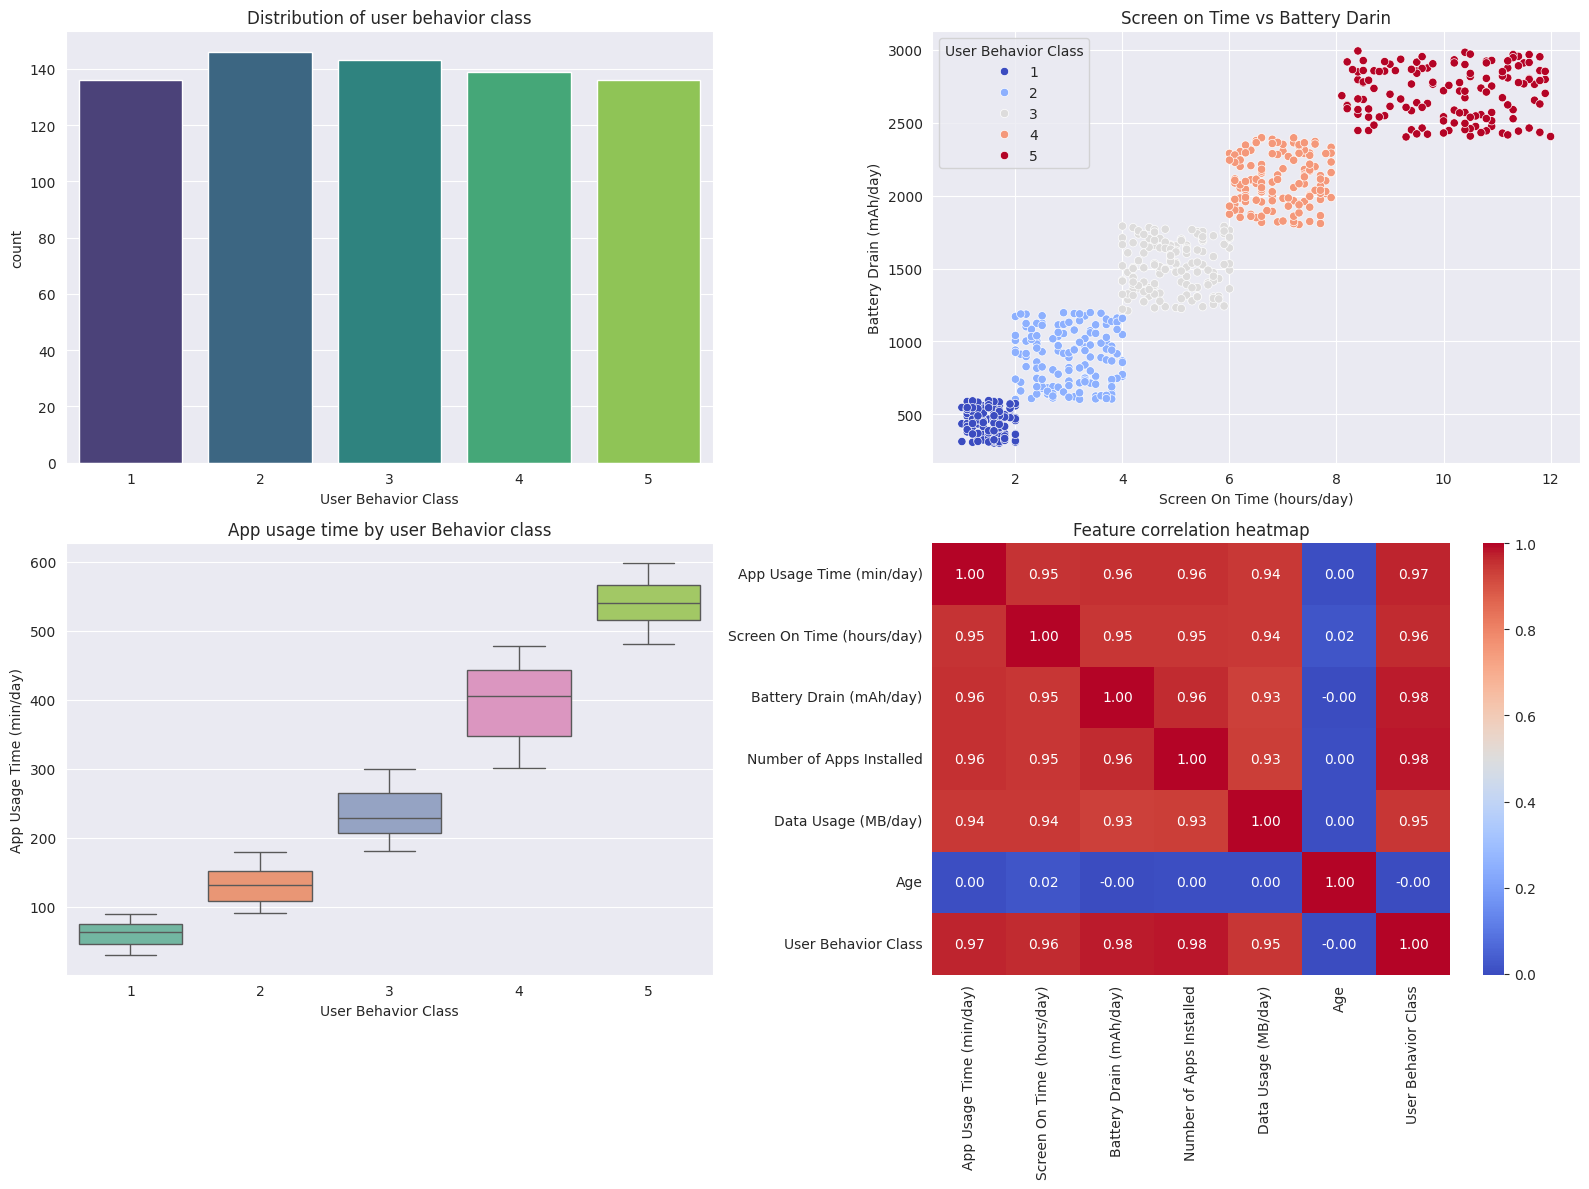

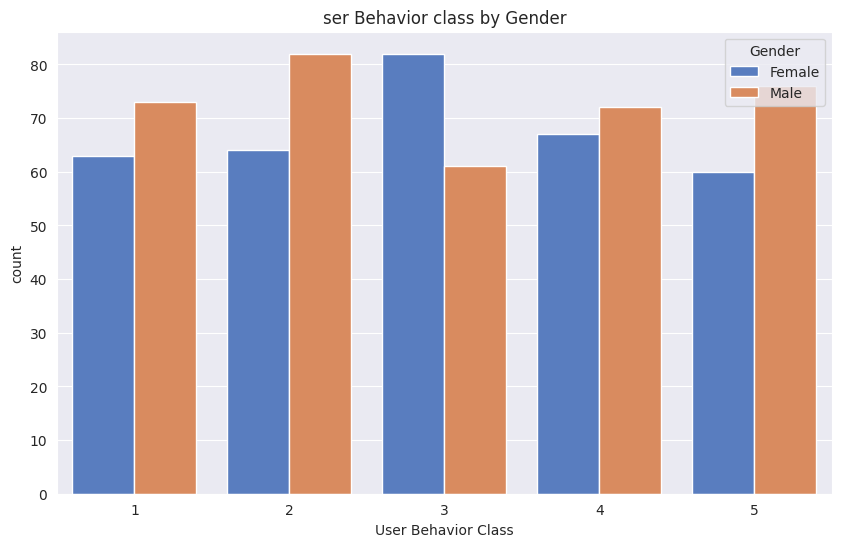

In [3]:
# #Creating a figure for several plots 
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. target Distribution
sns. countplot(data=df, x='User Behavior Class', palette='viridis', ax=axes[0, 0])
axes[0, 0].set_title('Distribution of user behavior class')

# 2. Relationship: Sreen on time VS Battery drain
sns.scatterplot(data=df, x='Screen On Time (hours/day)', y='Battery Drain (mAh/day)', hue='User Behavior Class', palette='coolwarm', ax=axes[0, 1])
axes[0, 1].set_title('Screen on Time vs Battery Darin')

# 3. Boxplot:App usage time per class
sns.boxplot(data=df, x='User Behavior Class', y='App Usage Time (min/day)', palette='Set2', ax=axes[1,0])
axes[1, 0].set_title('App usage time by user Behavior class')

# 4. Correlation Heatmap (only numerical)
numerical_df = df.select_dtypes(include=[np.number]).drop(columns=['User ID'])
sns.heatmap(numerical_df.corr(), annot=True, cmap='coolwarm', fmt='.2f', ax=axes[1, 1])
axes[1, 1].set_title('Feature correlation heatmap')

plt.tight_layout()
plt.savefig('Exploratory_plots.png')

# One more plot for Gender vs Behavior
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='User Behavior Class', hue='Gender', palette='muted')
plt.title('ser Behavior class by Gender')
plt.savefig('Gender_vs_behavior.png')

3. ## **Data Preparation**
To prepare the data for machine learning, we performed the following steps:

- **Feature Selection**: Dropped User ID as it provides no predictive value.

- **Categorical Encoding**: Converted Gender, Device Model, and Operating System into numerical formats using Label Encoding.

- **Data Splitting**: Divided the data into Training (80%) and Testing (20%) sets.

- **Feature Scaling**: Applied Standard Scaling to ensure features like Battery Drain (high values) don't dominate features like Screen On Time (low values).

In [4]:
# copy DataFrame for preprocessing
df_prep = df.copy()

# Drop User ID
df_prep = df_prep.drop(columns=['User ID'])

# Encoding categorical variables 
le = LabelEncoder()
df_prep['Device Model'] = le.fit_transform(df_prep['Device Model'])
df_prep['Operating System'] = le.fit_transform(df_prep['Operating System'])
df_prep['Gender'] = le.fit_transform(df_prep['Gender'])


# Defining FEatures and target
X = df_prep.drop(columns=['User Behavior Class'])
y = df_prep['User Behavior Class']

# Split the data
X_train, X_test, y_train, y_test  = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Feature Scaling 
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

4. ## **Modeling**
Implemented two classification algorithms to compare performance:

- **Random Forest Classifier**: An ensemble method that uses multiple decision trees.

- **Logistic Regression**: A baseline linear model for classification.

In [5]:
# 1. Random Forest
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train_scaled, y_train)
rf_preds= rf_model.predict(X_test_scaled)


# 2. Logistic Regression
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train_scaled, y_train)
lr_preds = lr_model.predict(X_test_scaled)

5. ## **Evaluation**
The models were evaluated using accuracy scores and a confusion matrix.

In [6]:
# Accuracy score 
rf_accuracy = accuracy_score(y_test, rf_preds)
lr_accuracy = accuracy_score(y_test, lr_preds)

print(f'Random Forest Accuracy: {rf_accuracy:.4f}')
print(f'Logistic Regression Accuracy: {lr_accuracy:.4f}')

Random Forest Accuracy: 1.0000
Logistic Regression Accuracy: 1.0000


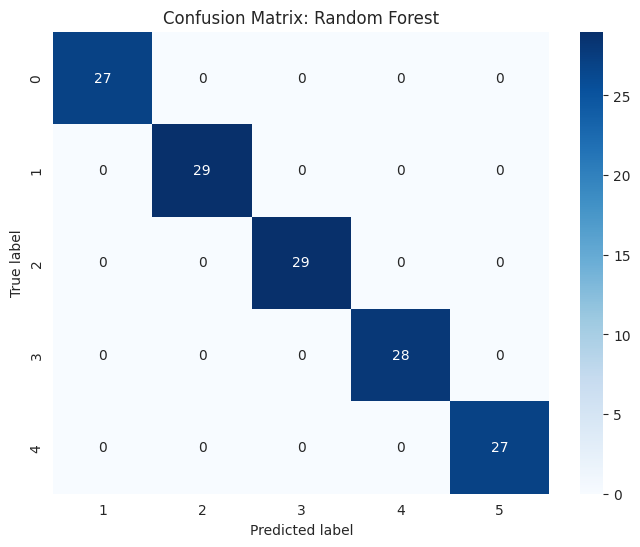

In [7]:
# Confusion Matrix for random forest 
cm = confusion_matrix(y_test, rf_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=np.unique(y))
plt.title('Confusion Matrix: Random Forest')
plt.xlabel('Predicted label')
plt.ylabel('True label')
plt.savefig('confusion_matrix_rf.png')

/tmp/ipykernel_6199/1503510280.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=feature_importance_df, x='Importance', y='Feature', palette='magma')



Feature Importance Table:
                      Feature  Importance
2    App Usage Time (min/day)    0.255720
4     Battery Drain (mAh/day)    0.228184
5    Number of Apps Installed    0.202652
6         Data Usage (MB/day)    0.198924
3  Screen On Time (hours/day)    0.112975
7                         Age    0.000972
0                Device Model    0.000419
8                      Gender    0.000154
1            Operating System    0.000000


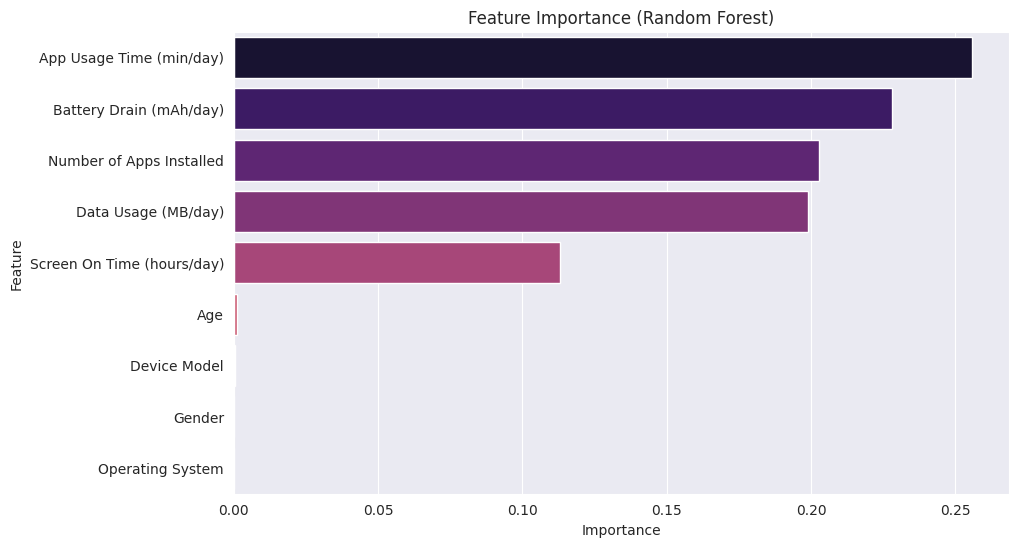

In [8]:
# Feature Importance
importances = rf_model.feature_importances_
feature_names = X.columns
feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=feature_importance_df, x='Importance', y='Feature', palette='magma')
plt.title('Feature Importance (Random Forest)')
plt.savefig('feature_importance.png')

print("\nFeature Importance Table:")
print(feature_importance_df)

## **Insights from Evaluation**:
- **Perfect Accuracy**: Both models achieved 100% accuracy on the test set. This indicates that the behavior classes are perfectly separable based on the provided features.

- **Feature Importance**: According to the Random Forest model, the top predictors are:

    - **App Usage Time (min/day)** (~25.6%)

    - **Battery Drain (mAh/day)** (~22.8%)

    - **Number of Apps Installed** (~20.3%)

- **Demographics**: Interestingly, Age, Gender, and Device Model had almost zero impact on the behavior class compared to usage intensity.

6. ## **Conclusion**
**Key Findings**:
- User classification is driven almost entirely by intensity of use (time spent and battery consumed).

- The "User Behavior Class" likely represents a spectrum from "Light User" (Class 1) to "Extreme Power User" (Class 5).

- Hardware factors like Operating System or Device Model do not significantly change the behavior classification in this dataset.